<a href="https://colab.research.google.com/github/TristanNguyen2311/Retail-Customer-Segmentation-with-RFM-Analysis-Python/blob/main/RFM_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CONTEXT**
RFM là một mô hình phân tích khách hàng dựa trên ba yếu tố chính:

Recency – R (Thời gian mua hàng gần nhất): Khoảng thời gian kể từ lần giao dịch gần nhất của khách hàng.

Frequency – F (Tần suất mua hàng): Số lần giao dịch khách hàng đã thực hiện trong khoảng thời gian nhất định.

Monetary – M (Giá trị tiền cho mỗi lần mua hàng): Tổng giá trị của các giao dịch mà khách hàng đã thực hiện trong một khoảng thời gian nhất định.

RFM là một phần của Marketing Analysis và được sử dụng để phân
tích giá trị khách hàng (Customer Value), giúp doanh nghiệp có thể phân tích ra từng nhóm khách
hàng mà mình đang có. Từ đó có những chiến dịch marketing hoặc chăm sóc đặc biệt.

# **PROBLEM STATEMENT**
Công ty SuperStore là một công ty bán lẻ trên toàn cầu - Global. Nên công ty có rất nhiều khách hàng.
Nhân dịp giáng sinh và năm mới, phòng Marketing muốn chạy các chiến dịch marketing để tri ân khách hàng đã ủng hộ công ty suốt thời gian qua. Cũng như khai thác các khách có tiềm năng trở thành khách hàng trung thành.

Tuy nhiên phòng Marketing vẫn chưa phân nhóm cho từng khách hàng của năm nay được vì tập dữ liệu quá lớn nên không thể xử lý bằng tay như các năm trước, nên nhờ Phòng Phân tích dữ liệu hỗ trợ triển khai một bài toán phân loại phân khúc của từng khách hàng để triển khai từng chương trình marketing phù hợp với từng nhóm khách hàng.

Giám đốc Marketing cũng có đề xuất phương án sử dụng mô hình RFM, tuy nhiên trước đây khi quy mô công ty nhỏ, team có thể tự tính và phân loại bằng excel. Hiện tại lượng data quá lớn nên mong muốn Phòng dữ liệu xây dựng luồng triển khai đánh giá Segmentation thông qua lập trình Python.

# **USER PROFILE DEFINITION**

## **Part 1: Exploratory Data Analysis (EDA)**

*   Understand about the data (data type, data value)
*   Check missing data type and handle missing data
*   Check duplicated data type and handle duplicated data
*   Check outliers and handle outliers












### 1.1 Understand about the data (data type, data value)

In [4]:
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Unigap/Python/RFM Segmentation'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Tự động cập nhật đường dẫn tệp

Để giúp notebook linh hoạt hơn khi bạn di chuyển tệp `ecommerce retail.csv` trong Google Drive, chúng ta có thể thêm một hàm tìm kiếm. Hàm này sẽ cố gắng tìm tệp trong `MyDrive` nếu đường dẫn mặc định không hoạt động. Khi tìm thấy, nó sẽ cập nhật biến `path` để các phần còn lại của notebook có thể sử dụng đường dẫn chính xác.

In [ ]:
import os

def find_file_in_drive(filename, search_start_path='/content/drive/MyDrive'):
    """
    Searches for a specified file within the user's Google Drive.

    Args:
        filename (str): The name of the file to search for.
        search_start_path (str): The starting directory for the search (default is MyDrive).

    Returns:
        str or None: The absolute path to the file if found, otherwise None.
    """
    for root, dirs, files in os.walk(search_start_path):
        if filename in files:
            return os.path.join(root, filename)
    return None


In [5]:
# Load Dataset
import pandas as pd
ecommerce_retail = pd.read_csv("/content/drive/MyDrive/Unigap/Python/RFM Segmentation/ecommerce retail.csv", encoding='latin1')
ecommerce_retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [6]:
# Detect the data type of each column
ecommerce_retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [7]:
# Convert data type
ecommerce_retail['InvoiceNo']= ecommerce_retail['InvoiceNo'].astype('string')
ecommerce_retail['StockCode']= ecommerce_retail['StockCode'].astype('string')
ecommerce_retail['Description']= ecommerce_retail['Description'].astype('string')
ecommerce_retail['InvoiceDate']= pd.to_datetime(ecommerce_retail['InvoiceDate'])
ecommerce_retail['CustomerID']= ecommerce_retail['CustomerID'].astype('string')
ecommerce_retail['Country']= ecommerce_retail['Country'].astype('string')

In [8]:
ecommerce_retail.shape

(541909, 8)

In [9]:
# Detect data value of columns
ecommerce_retail.describe()

,Quantity,InvoiceDate,UnitPrice
count,541909.000000,541909,541909.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114
min,-80995.000000,2010-12-01 08:26:00,-11062.060000
25%,1.000000,2011-03-28 11:34:00,1.250000
50%,3.000000,2011-07-19 17:17:00,2.080000
75%,10.000000,2011-10-19 11:27:00,4.130000
max,80995.000000,2011-12-09 12:50:00,38970.000000
std,218.081158,NaN,96.759853


In [10]:
!pip install ydata-profiling
from ydata_profiling import ProfileReport # Import the ProfileReport function


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 8.0 MB/s eta 0:00:00


/tmp/ipykernel_13658/591849180.py:2: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport # Import the ProfileReport function


In [11]:
profile = ProfileReport(ecommerce_retail)
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:08<00:00,  1.10s/it]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [12]:
# Check data category data types of column StockCode
stockcode_check = ecommerce_retail['StockCode'].value_counts()
stockcode_check

,count
StockCode,
85123A,2313
22423,2203
85099B,2159
47566,1727
20725,1639
...,...
84967A,1
84967B,1
84966B,1


In [13]:
# Check data category data types of column Description
description_check = ecommerce_retail['Description'].value_counts()
description_check

,count
Description,
WHITE HANGING HEART T-LIGHT HOLDER,2369
REGENCY CAKESTAND 3 TIER,2200
JUMBO BAG RED RETROSPOT,2159
PARTY BUNTING,1727
LUNCH BAG RED RETROSPOT,1638
...,...
check?,1
SET 10 CARDS TRIANGLE ICONS 17220,1
SET 10 CARDS CHRISTMAS BAUBLE 16954,1


In [14]:
description_check.to_csv(path + '/description_check.csv')

In [15]:
description_check_update = pd.read_csv(path + '/description_check.csv')

# Add column 'Error': True if any letter is not uppercase or contains only '?
description_check_update['Error'] = description_check_update['Description'].str.contains(r'[a-z]|\?', regex=True)
description_check_update

,Description,count,Error
0,WHITE HANGING HEART T-LIGHT HOLDER,2369,False
1,REGENCY CAKESTAND 3 TIER,2200,False
2,JUMBO BAG RED RETROSPOT,2159,False
3,PARTY BUNTING,1727,False
4,LUNCH BAG RED RETROSPOT,1638,False
...,...,...,...
4218,check?,1,True
4219,SET 10 CARDS TRIANGLE ICONS 17220,1,False
4220,SET 10 CARDS CHRISTMAS BAUBLE 16954,1,False
4221,wrongly marked,1,True


In [16]:
ecommerce_retail_update = ecommerce_retail.merge(description_check_update[['Description', 'Error']], on='Description', how='left')
print(ecommerce_retail_update[ecommerce_retail_update['Error'] == True].shape)
print(ecommerce_retail_update.shape)

(3092, 9)
(541909, 9)


In [17]:
# Check the reason for data quantity <0
ecommerce_retail_update[ecommerce_retail_update['Quantity'] < 0].head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Error
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,True
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,False
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,False
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,False
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,False


In [18]:
# Check if Quantity <0 is due to cancellation
ecommerce_retail_update[ecommerce_retail_update['InvoiceNo'].str.startswith('C') & (ecommerce_retail_update['Quantity'] < 0)].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Error
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,True
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,False
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,False
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,False
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,False


In [19]:
# Check if Quantity <0 that is not due to cancellation
ecommerce_retail_update[~ecommerce_retail_update['InvoiceNo'].str.startswith('C') & (ecommerce_retail_update['Quantity'] < 0)].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Error
2406,536589,21777,<NA>,-10,2010-12-01 16:50:00,0.0,<NA>,United Kingdom,NaN
4347,536764,84952C,<NA>,-38,2010-12-02 14:42:00,0.0,<NA>,United Kingdom,NaN
7188,536996,22712,<NA>,-20,2010-12-03 15:30:00,0.0,<NA>,United Kingdom,NaN
7189,536997,22028,<NA>,-20,2010-12-03 15:30:00,0.0,<NA>,United Kingdom,NaN
7190,536998,85067,<NA>,-6,2010-12-03 15:30:00,0.0,<NA>,United Kingdom,NaN


In [20]:
# Check the reason for Unit Price <0
ecommerce_retail_update[ecommerce_retail_update['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Error
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,<NA>,United Kingdom,True
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,<NA>,United Kingdom,True


In [21]:
# Check data types
ecommerce_retail_update.dtypes

,0
InvoiceNo,string[python]
StockCode,string[python]
Description,object
Quantity,int64
InvoiceDate,datetime64[ns]
UnitPrice,float64
CustomerID,string[python]
Country,string[python]
Error,object


**Nhận xét:**
- Có các cột chưa đúng data type nên convert về đúng dạng
- Có missing values ở cột Description và cột CustomerID
- Cột Description có 3092 đơn hàng có nội dung mô tả không chính xác
- Gần 88% các trường hợp có Quantity <0 là do bị cancle, 12% các trường hợp còn lại đến từ các lí do như: thất lạc, hư hỏng, đang kiểm tra lại hoặc chưa có thông tin và ta có thể thấy UnitPrice = 0
- 2 trường hợp có UnitPrice < 0 là do điều chỉnh nợ xấu

### 1.2 Handle incorrect values

In [22]:
# Remove orders with Quantity <=0 (including canceled orders)
ecommerce_retail_update = ecommerce_retail_update[ecommerce_retail_update['Quantity'] > 0]
ecommerce_retail_update.shape


(531285, 9)

In [23]:
# Remove orders with UnitPrice <=0
ecommerce_retail_update = ecommerce_retail_update[ecommerce_retail_update['UnitPrice'] > 0]
ecommerce_retail_update.shape

(530104, 9)

### 1.3 Handle missing values

In [24]:
# Check missing value
missing_values = ecommerce_retail_update.isnull().sum()
missing_percentage = (ecommerce_retail_update.isnull().sum() / len(ecommerce_retail_update)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Missing Percentage': missing_percentage})
missing_df

,Missing Values,Missing Percentage
InvoiceNo,0,0.000000
StockCode,0,0.000000
Description,0,0.000000
Quantity,0,0.000000
InvoiceDate,0,0.000000
UnitPrice,0,0.000000
CustomerID,132220,24.942275
Country,0,0.000000
Error,0,0.000000


In [25]:
# Check the rows with missing CustomerID to understand the reason
ecommerce_retail_update[ecommerce_retail_update['CustomerID'].isna()].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Error
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,<NA>,United Kingdom,False
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,<NA>,United Kingdom,False
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,<NA>,United Kingdom,False
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,<NA>,United Kingdom,False
1447,536544,21790,VINTAGE SNAP CARDS,9,2010-12-01 14:32:00,1.66,<NA>,United Kingdom,False


In [26]:
# Create a month column to check for missing values by month
ecommerce_retail_update['day'] = ecommerce_retail_update['InvoiceDate'].dt.date
ecommerce_retail_update['month'] = ecommerce_retail_update['InvoiceDate'].dt.strftime('%Y-%m')
ecommerce_retail_update.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Error,day,month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,2010-12-01,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,2010-12-01,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,2010-12-01,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,2010-12-01,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,2010-12-01,2010-12


In [27]:
ecommerce_retail_update[ecommerce_retail_update['CustomerID'].isna()]['month'].value_counts().sort_index()

,count
month,
2010-12,15323
2011-01,13077
2011-02,7178
2011-03,8628
2011-04,6454
2011-05,7844
2011-06,8792
2011-07,11820
2011-08,7476


In [28]:
# Remove missing values in the CustomerID column
ecommerce_retail_update = ecommerce_retail_update[ecommerce_retail_update['CustomerID'].notnull()]
ecommerce_retail_update.shape

(397884, 11)

**Nhận xét**

- Cột CustomerID có 132220 missing value (chiếm gần 25%)
- Tháng nào cũng đều có missing value do đó cần check lại hệ thống hay quy trình lưu trữ data để khắc phục
- Customer ID là dữ liệu quan trọng không thể thay thế nên chỉ có thể xóa đi

### 1.4 Handle duplicate values

In [29]:
# Check duplicate values
duplicates_df= ecommerce_retail_update.duplicated(subset=['InvoiceNo','StockCode','InvoiceDate','CustomerID'])
ecommerce_retail_update[duplicates_df].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Error,day,month
125,536381,71270,PHOTO CLIP LINE,3,2010-12-01 09:41:00,1.25,15311.0,United Kingdom,False,2010-12-01,2010-12
498,536409,90199C,5 STRAND GLASS NECKLACE CRYSTAL,1,2010-12-01 11:45:00,6.35,17908.0,United Kingdom,False,2010-12-01,2010-12
502,536409,85116,BLACK CANDELABRA T-LIGHT HOLDER,5,2010-12-01 11:45:00,2.10,17908.0,United Kingdom,False,2010-12-01,2010-12
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom,False,2010-12-01,2010-12
525,536409,90199C,5 STRAND GLASS NECKLACE CRYSTAL,2,2010-12-01 11:45:00,6.35,17908.0,United Kingdom,False,2010-12-01,2010-12


In [30]:
# Check specific InvoiceNos that are duplicated
ecommerce_retail_update[(ecommerce_retail_update['InvoiceNo'] == '536381') & (ecommerce_retail_update['StockCode'] == '71270')]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Error,day,month
113,536381,71270,PHOTO CLIP LINE,1,2010-12-01 09:41:00,1.25,15311.0,United Kingdom,False,2010-12-01,2010-12
125,536381,71270,PHOTO CLIP LINE,3,2010-12-01 09:41:00,1.25,15311.0,United Kingdom,False,2010-12-01,2010-12


In [31]:
ecommerce_retail_update[(ecommerce_retail_update['InvoiceNo'] == '581538') & (ecommerce_retail_update['StockCode'] == '22992')]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Error,day,month
541640,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom,False,2011-12-09,2011-12
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom,False,2011-12-09,2011-12


In [32]:
# Retain the last instance of a row if duplicates exist with varying quantities
ecommerce_retail_update = ecommerce_retail_update.drop_duplicates(subset=['InvoiceNo', 'StockCode', 'InvoiceDate', 'CustomerID'],keep='last')

In [33]:
# Delete duplicate rows and retain only the first instance
ecommerce_retail_update = ecommerce_retail_update.drop_duplicates(keep='first')

In [34]:
ecommerce_retail_update

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Error,day,month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,2010-12-01,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,2010-12-01,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,2010-12-01,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,2010-12-01,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,2010-12-01,2010-12
...,...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,False,2011-12-09,2011-12
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,False,2011-12-09,2011-12
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,False,2011-12-09,2011-12
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,False,2011-12-09,2011-12


**Nhận xét**

- Có 10038 hàng bị duplicated
- 2 hàng chỉ khác nhau về Quantity nguyên nhân đến từ việc ngay sau khi đặt hàng KH đã bấm thay đổi số lượng nhưng do hệ thống bị lỗi hay xảy ra vấn đề nên đã lưu thành 2 đơn hàng
- 2 hàng giống nhau hoàn toàn nguyên nhân do hệ thống bị lỗi nên dữ liệu đã bị duplicated

## **PART 2: Data Processing**

In [35]:
# Create Recency, Frequency, and Monetary variables
# Take the last date as the baseline
Lastday = ecommerce_retail_update['day'].max()
# Create Cost column
ecommerce_retail_update['Spend'] = ecommerce_retail_update['Quantity'] * ecommerce_retail_update['UnitPrice']

# Calculate the Recency, Frequency, and Monetary values
rfm = ecommerce_retail_update.groupby('CustomerID').agg(
                                                        Recency = ('day', lambda x: -(Lastday - x.max()).days),
                                                        Frequency =('CustomerID', lambda x: x.count()) ,
                                                        Monetary = ('Spend', lambda x: x.sum())
                                                        ).reset_index()

# Adjust data types
rfm['Frequency'] = rfm['Frequency'].astype('int')
rfm.dtypes

,0
CustomerID,string[python]
Recency,int64
Frequency,int64
Monetary,float64


In [36]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,-325,1,77183.60
1,12347.0,-2,182,4310.00
2,12348.0,-75,27,1744.44
3,12349.0,-18,73,1757.55
4,12350.0,-310,17,334.40


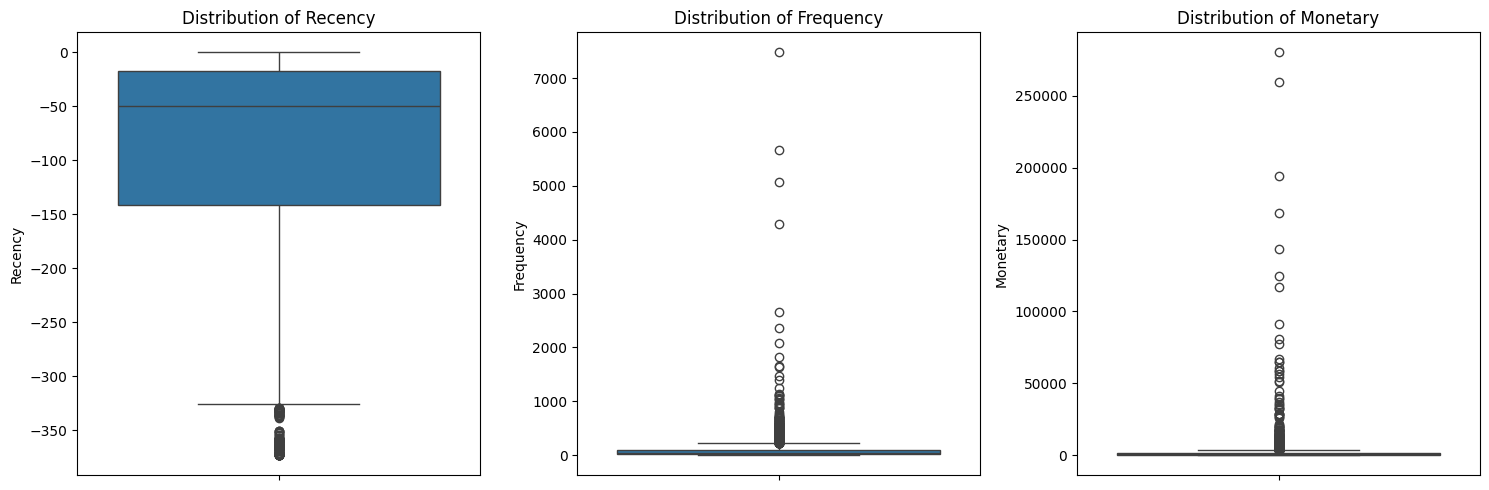

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure and a set of subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot the distribution of Recency
sns.boxplot(rfm['Recency'], ax=axes[0])
axes[0].set_title('Distribution of Recency')

# Plot the distribution of Frequency
sns.boxplot(rfm['Frequency'], ax=axes[1])
axes[1].set_title('Distribution of Frequency')

# Plot the distribution of Monetary
sns.boxplot(rfm['Monetary'], ax=axes[2])
axes[2].set_title('Distribution of Monetary')

# Adjust the layout and display the plot
plt.tight_layout()
plt.show()

In [38]:
# Remove outliers
seventy_fifth = rfm['Recency'].quantile(0.75)
twenty_fifth = rfm['Recency'].quantile(0.25)
Recency_iqr = seventy_fifth - twenty_fifth
Recency_upper = seventy_fifth + (1.5 * Recency_iqr)
Recency_lower = twenty_fifth - (1.5 * Recency_iqr)


seventy_fifth = rfm['Frequency'].quantile(0.75)
twenty_fifth = rfm['Frequency'].quantile(0.25)
Frequency_iqr = seventy_fifth - twenty_fifth
Frequency_upper = seventy_fifth + (1.5 * Frequency_iqr)
Frequency_lower = twenty_fifth - (1.5 * Frequency_iqr)


seventy_fifth = rfm['Monetary'].quantile(0.75)
twenty_fifth = rfm['Monetary'].quantile(0.25)
Monetary_iqr = seventy_fifth - twenty_fifth
Monetary_upper = seventy_fifth + (1.5 * Monetary_iqr)
Monetary_lower = twenty_fifth - (1.5 * Monetary_iqr)

rfm_drop_outliers =rfm[
                       (rfm['Recency'] > Recency_lower) & (rfm['Recency'] < Recency_upper) &
                       (rfm['Frequency'] > Frequency_lower) & (rfm['Frequency'] < Frequency_upper) &
                       (rfm['Monetary'] > Monetary_lower)& (rfm['Monetary'] < Monetary_upper)
                       ]
rfm_drop_outliers.shape

(3612, 4)

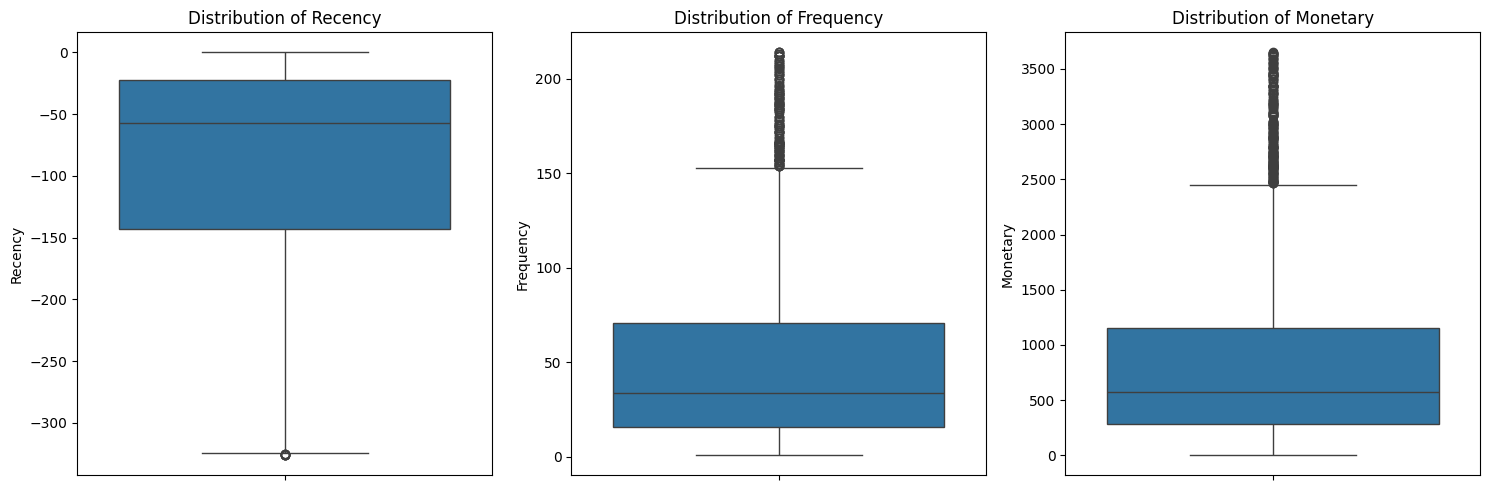

In [39]:
# Create a figure and a set of subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot the distribution of Recency
sns.boxplot(rfm_drop_outliers['Recency'], ax=axes[0])
axes[0].set_title('Distribution of Recency')

# Plot the distribution of Frequency
sns.boxplot(rfm_drop_outliers['Frequency'], ax=axes[1])
axes[1].set_title('Distribution of Frequency')

# Plot the distribution of Monetary
sns.boxplot(rfm_drop_outliers['Monetary'], ax=axes[2])
axes[2].set_title('Distribution of Monetary')

# Adjust the layout and display the plot
plt.tight_layout()
plt.show()

In [40]:
# Use qcut to create R, M, F
rfm_drop_outliers['R'] = pd.qcut(rfm_drop_outliers['Recency'], 5, labels=range(1,6)).astype(str)
rfm_drop_outliers['F'] = pd.qcut(rfm_drop_outliers['Frequency'], 5, labels=range(1,6)).astype(str)
rfm_drop_outliers['M'] = pd.qcut(rfm_drop_outliers['Monetary'], 5, labels=range(1,6)).astype(str)
rfm_drop_outliers['RFM'] = rfm_drop_outliers['R'] + rfm_drop_outliers['F'] + rfm_drop_outliers['M']
rfm_drop_outliers.head()

/tmp/ipykernel_13658/2725855072.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm_drop_outliers['R'] = pd.qcut(rfm_drop_outliers['Recency'], 5, labels=range(1,6)).astype(str)
/tmp/ipykernel_13658/2725855072.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rfm_drop_outliers['F'] = pd.qcut(rfm_drop_outliers['Frequency'], 5, labels=range(1,6)).astype(str)
/tmp/ipykernel_13658/2725855072.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row

,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM
2,12348.0,-75,27,1744.44,2,3,5,235
3,12349.0,-18,73,1757.55,4,4,5,445
4,12350.0,-310,17,334.40,1,2,2,122
5,12352.0,-36,83,1849.49,4,4,5,445
6,12353.0,-204,4,89.00,1,1,1,111


In [41]:
# Load data segmentation
segmentation = pd.read_csv(path + '/segmentation.csv')
segmentation.head()

,Segment,RFM Score
0,Champions,"555, 554, 544, 545, 454, 455, 445"
1,Loyal,"543, 444, 435, 355, 354, 345, 344, 335"
2,Potential Loyalist,"553, 551, 552, 541, 542, 533, 532, 531, 452, 4..."
3,New Customers,"512, 511, 422, 421, 412, 411, 311"
4,Promising,"525, 524, 523, 522, 521, 515, 514, 513, 425,42..."


In [42]:
segmentation['RFM Score']= segmentation['RFM Score'].astype('string').str.split(',')
segmentation = segmentation.explode('RFM Score')
segmentation['RFM Score'] = segmentation['RFM Score'].apply(lambda x: x.replace(' ',''))
segmentation.head()

,Segment,RFM Score
0,Champions,555
0,Champions,554
0,Champions,544
0,Champions,545
0,Champions,454


In [43]:
# Merge segmentation
final_rfm = rfm_drop_outliers.merge(segmentation, left_on='RFM', right_on='RFM Score', how='left')
final_rfm.head()

,CustomerID,Recency,Frequency,Monetary,R,F,M,RFM,Segment,RFM Score
0,12348.0,-75,27,1744.44,2,3,5,235,At Risk,235
1,12349.0,-18,73,1757.55,4,4,5,445,Champions,445
2,12350.0,-310,17,334.40,1,2,2,122,Hibernating customers,122
3,12352.0,-36,83,1849.49,4,4,5,445,Champions,445
4,12353.0,-204,4,89.00,1,1,1,111,Lost customers,111


**Mô tả quá trình**

- Tính Recency, Frequency và Monetary của từng khách hàng
- Loại bỏ Outliers
- Chia Recency, Frequency và Monetary thành 5 phân vị từ đó tính được điểm RFM của từng khách hàng
- Load file segmentation
- Kết hợp bảng rfm_drop_outliers và bảng segmentation bằng điểm RFM để phân loại khách hàng theo từng CustormerID

## **PART 3: Visualization**

### 3.1 Overall the distribution of the RFM Modelling

In [44]:
import matplotlib.pyplot as plt
!pip install squarify
import squarify

In [45]:
# Create a function for wrapping text
import textwrap
def wrap_text(text, width=12):  # Adjust width
    return "\n".join(textwrap.wrap(text, width=width))

In [46]:
Custom_colors = ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78', '#2ca02c', '#98df8a', '#d62728', '#ff9896', '#9467bd', '#c5b0d5', '#8c564b']

In [47]:
# Users by segment
segment_usercnt = final_rfm[['Segment','CustomerID']].groupby(['Segment']).count().reset_index().rename(columns={'CustomerID':'user_cnt'})
# Percentage of users by segment
segment_usercnt['volumn_percent'] = ((segment_usercnt['user_cnt']/segment_usercnt['user_cnt'].sum())*100).round(0)
segment_usercnt['Segment'] = segment_usercnt['Segment'] + ' ' + segment_usercnt['volumn_percent'].astype(int).astype(str) + '%'
segment_usercnt

,Segment,user_cnt,volumn_percent
0,About To Sleep 4%,144,4.0
1,At Risk 12%,428,12.0
2,Cannot Lose Them 3%,107,3.0
3,Champions 15%,549,15.0
4,Hibernating customers 17%,612,17.0
5,Lost customers 9%,324,9.0
6,Loyal 10%,345,10.0
7,Need Attention 5%,183,5.0
8,New Customers 8%,298,8.0
9,Potential Loyalist 13%,471,13.0


In [48]:
# Calculate the average values
rfm_score_means = final_rfm.groupby('RFM Score').agg({
                                                      'Recency':'mean',
                                                      'Frequency':'mean',
                                                      'Monetary':'mean'
                                                      }).reset_index()


rfm_score_means = rfm_score_means.reset_index()

rfm_score_means.head()


,index,RFM Score,Recency,Frequency,Monetary
0,0,111,-251.890547,6.776119,131.319552
1,1,112,-242.092593,8.351852,308.373889
2,2,113,-261.333333,6.133333,573.636000
3,3,114,-219.166667,7.250000,931.019167
4,4,115,-239.666667,5.333333,2292.903333


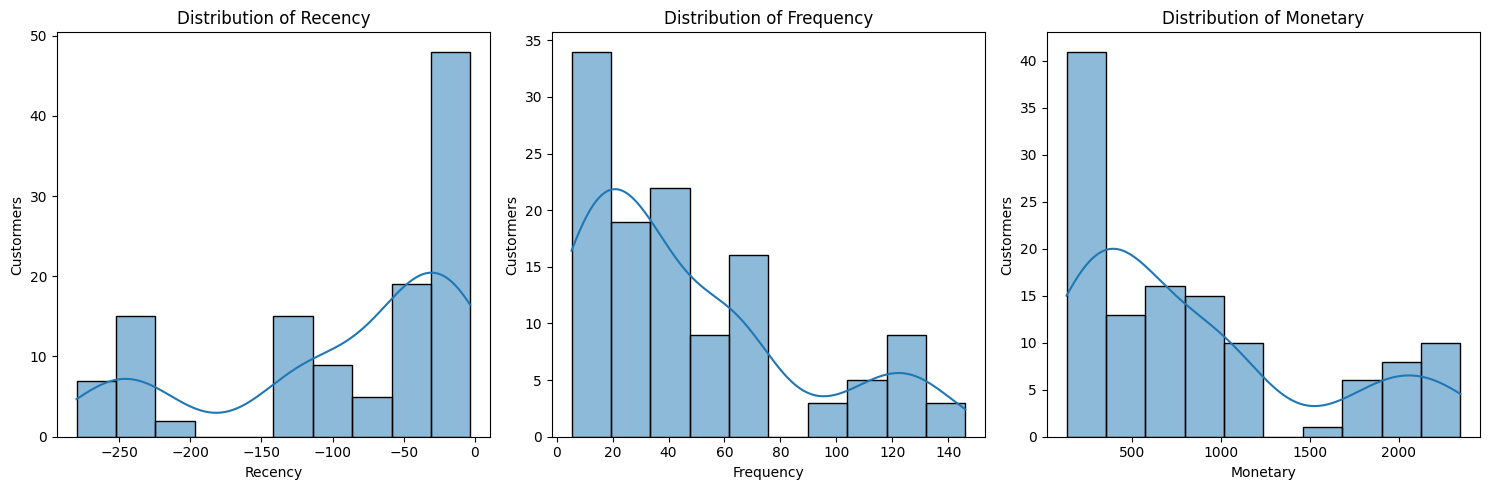

In [49]:
# Create subplots for each metric
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot histograms for each metric
sns.histplot(rfm_score_means['Recency'], ax=axes[0], bins=10, kde=True)
axes[0].set_title('Distribution of Recency')
axes[0].set_xlabel('Recency')
axes[0].set_ylabel('Custormers')

sns.histplot(rfm_score_means['Frequency'], ax=axes[1], bins=10, kde=True)
axes[1].set_title('Distribution of Frequency')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Custormers')

sns.histplot(rfm_score_means['Monetary'], ax=axes[2], bins=10, kde=True)
axes[2].set_title('Distribution of Monetary')
axes[2].set_xlabel('Monetary')
axes[2].set_ylabel('Custormers')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

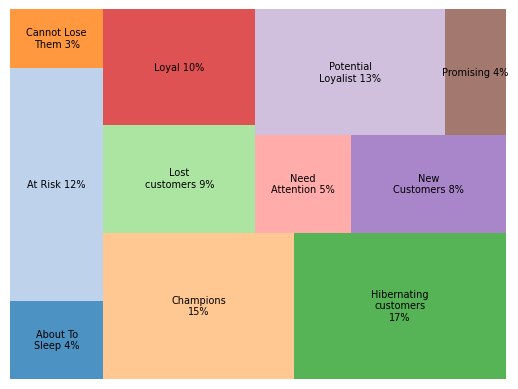

In [50]:
# Use the text wrapping function to the Segment column
segment_usercnt['Segment_wrapped'] = segment_usercnt['Segment'].apply(wrap_text)

# Create treemap
squarify.plot(sizes=segment_usercnt['user_cnt'], label=segment_usercnt['Segment_wrapped'], color=Custom_colors, alpha=0.8,text_kwargs={'fontsize': 7})
plt.axis('off')
plt.show()

### 3.2 Distribution of RFM Modelling by time

In [51]:
Custom_colors = ['#1f77b4', '#aec7e8', '#ff7f0e', '#ffbb78', '#2ca02c', '#98df8a', '#d62728', '#ff9896', '#9467bd', '#c5b0d5', '#8c564b']

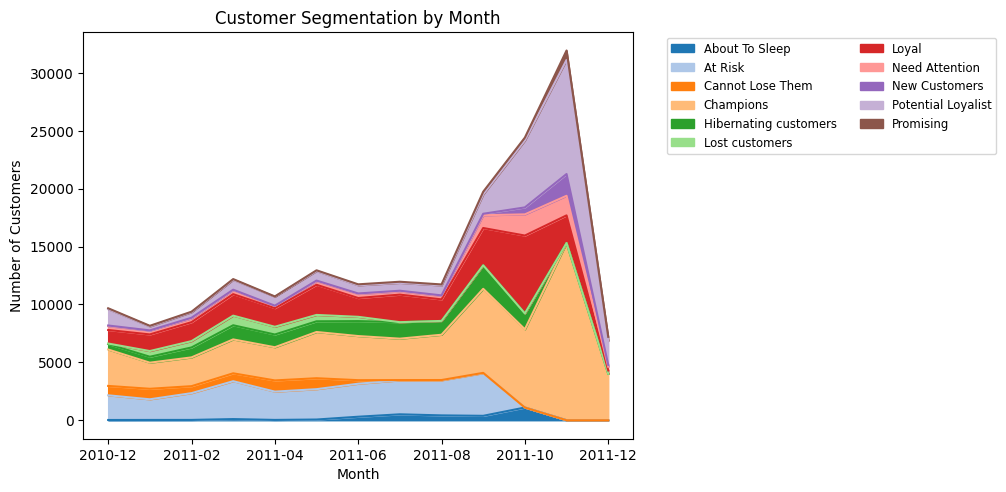

In [52]:
# Segment user by time
rmf_customer_month = pd.merge(final_rfm, ecommerce_retail_update[['CustomerID','month']], on='CustomerID', how='left')
rmf_customer_month = rmf_customer_month.groupby(['month','Segment']).agg({'CustomerID':'count'}).reset_index().rename(columns={'CustomerID':'user_cnt'})
rmf_customer_month = rmf_customer_month.pivot_table(values='user_cnt', index='month', columns='Segment', fill_value =0)

# Create area chart
customer_month = rmf_customer_month.plot(kind='area', stacked=True, color=Custom_colors) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent overlapping
customer_month.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
plt.xlabel("Month")
plt.ylabel("Number of Customers")
plt.title("Customer Segmentation by Month")
plt.show()

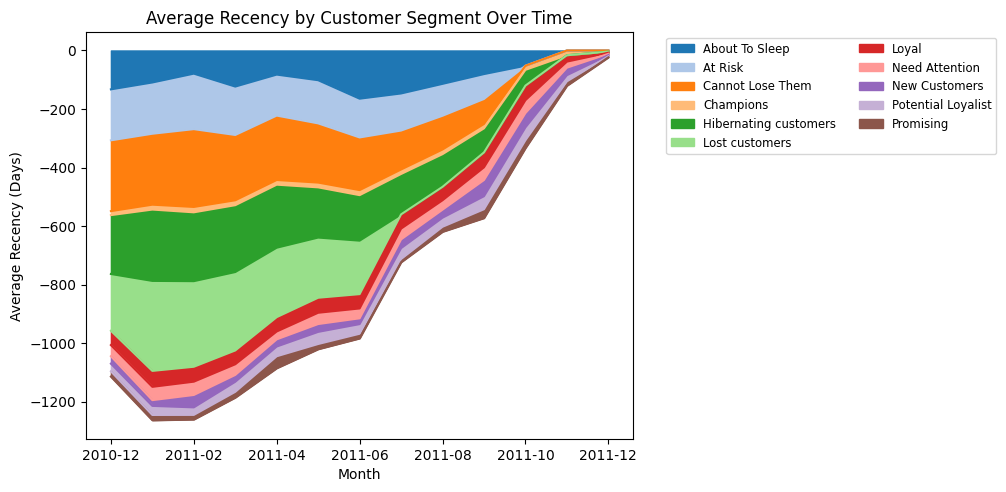

In [53]:
# Segment recency by time
rmf_recency_month = pd.merge(final_rfm, ecommerce_retail_update[['CustomerID','month']], on='CustomerID', how='left')
rmf_recency_month = rmf_recency_month.groupby(['month','Segment']).agg({'Recency':'mean'}).reset_index()
rmf_recency_month = rmf_recency_month.pivot_table(values='Recency', index='month', columns='Segment', fill_value =0)

# Create area chart
recency_month = rmf_recency_month.plot(kind='area', stacked=True, color=Custom_colors)
plt.tight_layout() # Adjust layout to prevent overlapping
recency_month.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
plt.xlabel("Month")
plt.ylabel("Average Recency (Days)")
plt.title("Average Recency by Customer Segment Over Time")
plt.show()

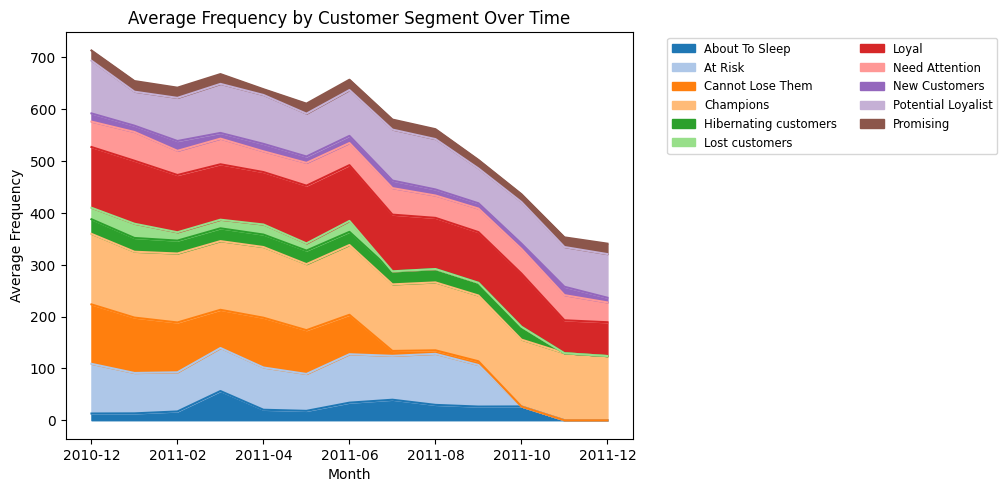

In [54]:
# Segment frequency by time
rmf_frequency_month = pd.merge(final_rfm, ecommerce_retail_update[['CustomerID','month']], on='CustomerID', how='left')
rmf_frequency_month = rmf_frequency_month.groupby(['month','Segment']).agg({'Frequency':'mean'}).reset_index()
rmf_frequency_month = rmf_frequency_month.pivot_table(values='Frequency', index='month', columns='Segment', fill_value =0)

# Create area chart
frequency_month = rmf_frequency_month.plot(kind='area', stacked=True, color=Custom_colors)
plt.tight_layout() # Adjust layout to prevent overlapping
frequency_month.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
plt.xlabel("Month")
plt.ylabel("Average Frequency")
plt.title("Average Frequency by Customer Segment Over Time")
plt.show()

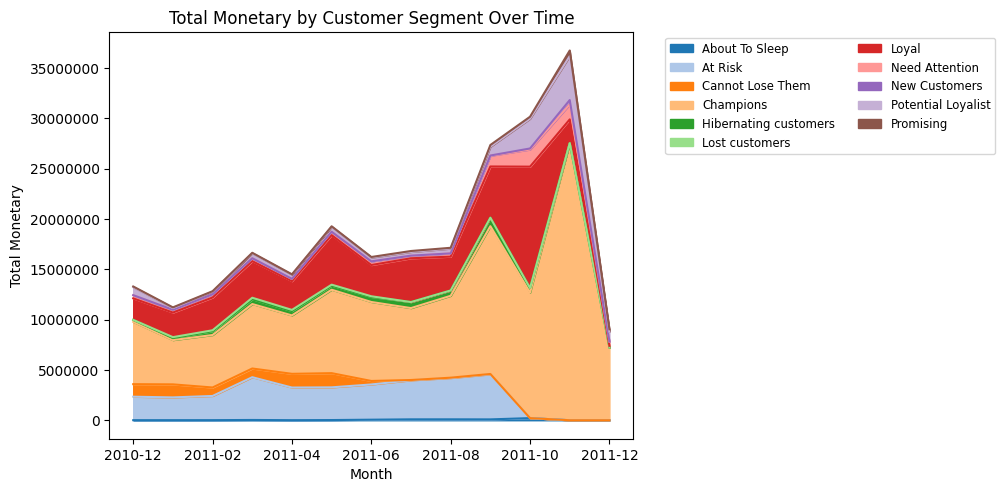

In [55]:
# Segment monetary by time
rmf_monetary_month = pd.merge(final_rfm, ecommerce_retail_update[['CustomerID','month']], on='CustomerID', how='left')
rmf_monetary_month = rmf_monetary_month.groupby(['month','Segment']).agg({'Monetary':'sum'}).reset_index()
rmf_monetary_month = rmf_monetary_month.pivot_table(values='Monetary', index='month', columns='Segment', fill_value =0)

# Create area chart
monetary_month = rmf_monetary_month.plot(kind='area', stacked=True, color=Custom_colors)
plt.ticklabel_format(axis='y', style='plain')
plt.tight_layout() # Adjust layout to prevent overlapping
monetary_month.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
plt.xlabel("Month")
plt.ylabel("Total Monetary")
plt.title("Total Monetary by Customer Segment Over Time")
plt.show()

## **PART 4: Insight**

- Nhóm khách hàng chiếm tỉ trọng lớn nhất là: Hibernating Customers(17%), Champions(15%), Potential Loyalist(13%), At risk(12%)
- Chỉ số Recency cho thấy khách hàng quay trở lại mua hàng nhiều khoảng tháng 10 và 11, đặc biệt là số lượng khách hàng mới tăng đáng kể.
- Chỉ số Frequency cho thấy hầu hết các nhóm khách hàng có tần suất mua hàng giảm dần theo thời gian, đây là điều đang lo ngại.
- Chỉ số Monetary cho thấy doanh thu chủ yếu đến từ nhóm Champions, Loyal, Potential Loyal và tăng mạnh trong tháng 9,10,11.

## **PART 5: Recommendation**

- Tỉ lệ khách hàng Hibernating và At risk chiếm tương đối cao, công ty nên có các cuộc gọi và làm các cuộc khảo sát để tìm hiểu nguyên nhân tại sao họ ít mua hàng và từ đó khắc phục cũng như đưa ra các chương trình khuyến mãi hấp dẫn nhằm thu hút 2 nhóm khách hàng này mua hàng trở lại.
- Khách hàng có xu hướng mua hàng nhiều vào tháng 9,10,11 đây là thời gian họ trang trí nhà cửa, mua sắm đồ dùng cần thiết  để chuẩn bị cho dịp Giáng Sinh và Năm Mới. Vì vậy đây là khoảng thời gian tốt để công ty thu hút chuyển đổi nhóm khách hàng bằng các sản phẩm chất lượng, các vouchers hấp dẫn và đặc biệt cung cấp chất lượng dịch vụ tốt.
- Phân tích các nguyên nhân dẫn đến giảm tần suất mua hàng của các nhóm khách hàng, cải thiện các chiến dịch marketing và những chương trình đặc quyền dành cho nhóm khách hàng thân thiết.
- Công ty nên quan tâm vào chỉ số Recency nhất vì có thể đánh giá được tình hình kinh doanh của công ty và hiệu quả của các chiến dịch tiếp thị. Từ đó lên các chiến lược phù hợp tăng số lượng khách hàng và giữ chân khách hàng.